# Do adopters already know the partner words?

**Artifact:** `art_FZ2OCJwV6xHs` (evaluation, iteration 4). The label is *screen-fold mechanism evidence, not confirmation*, and all exposure is *corpus-exposure, coverage-limited*.

**The question.** At the entry level (D2), a scientific concept `c` that enters a host subfield `d` attracts more author-disjoint newcomer uptake when its partner concepts are already *native* to the host. This is the anchoring effect `A_cont`, with IRR/SD 1.30. This evaluation tests the actor-level version of that mechanism. The newcomers who adopt `c` in `d` are the **cases**. Did they already use `c`'s partner vocabulary *before* the entry year `e`, and did they use it more than matched host authors who did not adopt (the **controls**)?

**What `eval.py` does.** It runs in stages:
1. `prepare`: reproduction gate on the co-primary D2 sample.
2. `frame`: build case / incidence-density control strata, and build the target concept sets P, NEG and PLAC.
3. `freeze`: hash the spec and compute MDEs *before* any exposure is read.
4. `pull`: guarded OpenAlex validation pull. It spent 0 credits.
5. `analyze`: compute exposures, fit conditional-logit enrichment models with a concept-cluster bootstrap, run the placebos and the permutation null, fit the entry-level PPML mediation, then give the pre-declared reading.

**What this notebook runs.** Stages 1–4 and the exposure computation need the 463k-work OpenAlex corpus and the upstream exp_7 files, so they cannot run here. The notebook starts from the **frozen exposure frame** (`results/exposures_primary.parquet`) of the full run and re-executes the whole **matched-strata analysis** of `stage_analyze` on a subset of **100 matched strata**:
- M-i enrichment, the placebos and the OR ratios
- M-ii interaction with `A_cont`
- M-iii vocabulary class
- the permutation null and the statsmodels check
- supplementary subsets and the origin-subfield check
- the pre-declared `reading()`

The code is copied from `eval.py`, `src/analysis.py`, `src/stats_core.py` and `src/figs.py`. The entry-level PPML mediation (M-iv) and the power simulation are loaded from the full run, because `reading()` needs them.

With 100 of the 1,013 strata and a small bootstrap, confidence intervals are much wider than in the full run. The final cell compares the demo to the full-run numbers.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib, statsmodels — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0', 'statsmodels==0.14.6')

## Imports

This is the original import block of `eval.py` plus the imports of `src/analysis.py`, `src/stats_core.py` and `src/figs.py`. The original logs to stdout *and* to `logs/eval.log`. The notebook keeps only the stdout sink.

`mech_common` (`mc`) holds the corpus paths, the vendored exp_7 code and a few constants. Only two of its constants are used by the analysis code below, `mc.SEED` and `mc.LABEL`, so a small namespace stands in for it.

In [2]:
from __future__ import annotations

import argparse
import hashlib
import re
import json
import sys
import time
import warnings
from datetime import datetime, timezone
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
from loguru import logger
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
import logging

logging.getLogger("fontTools").setLevel(logging.WARNING)

# stand-in for src/mech_common.py (only the constants the analysis code references)
mc = SimpleNamespace(SEED=20260929, LABEL="screen-fold mechanism evidence, not confirmation")

## Data loading
The loader tries the GitHub copy of `mini_demo_data.json` first and falls back to a local file.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/main/round-4/evaluation-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
meta = data["metadata"]
print(meta["description"])
print(f"{len(data['examples'])} strata loaded; label: {meta['label']} | {meta['exposure_label']}")

100 matched adopter strata (1 newcomer adopter = case, 1 matched control, up to 2 reserve controls) sampled from the 1,013-stratum primary frame of the adopter-level absorptive-capacity evaluation (screen fold; corpus-exposure, coverage-limited). Stratified by A_cont tercile ({1: 30, 2: 30, 3: 40}), seed 20260929.
100 strata loaded; label: screen-fold mechanism evidence, not confirmation | corpus-exposure, coverage-limited


## Configuration

These are all the tunable parameters. The bootstrap and permutation counts are the **original full-run values**; at 100 strata the notebook still runs in about a minute. The only reduction is the data: 100 of the 1,013 matched strata. For a quick smoke run, set `B = 20`, `N_PERM = 10`, `Bs = 10`, `B_ORIGIN = 10`.

| Parameter | What it controls | Original |
|---|---|---|
| `B` | concept-cluster bootstrap replicates for the full model suite | 1000 |
| `N_PERM` | permutation-null draws (within-stratum case-label reshuffles) | 200 |
| `Bs` | bootstrap replicates for supplementary subsets | `max(B // 5, 50)` = 200 |
| `B_ORIGIN` | bootstrap replicates for the post-hoc origin-subfield check | 1000 |
| `N_STRATA` | matched strata used, taken from the 100 in the demo file | 1013 in the full frame |

In [5]:
B = 1000         # original: 1000   (eval.py --B default)
N_PERM = 200     # original: 200    (permutation_null reps; 50 in --mini)
Bs = max(B // 5, 50)  # original: max(B // 5, 50) = 200
B_ORIGIN = B     # original: B = 1000 (stage_extra bootstrap_one; 100 in --mini)
N_STRATA = 100   # original: all 1,013 primary strata (the demo file holds 100)

## Statistical core (`src/stats_core.py`, verbatim)

- `clogit` is a fast Newton–Raphson **conditional logistic regression**. There is one case per matched stratum; the stratum-specific intercepts are conditioned out. It returns model-based SEs and concept-cluster-robust (CRV) SEs. In the full run it matched statsmodels' `ConditionalLogit` to within 7e-5.
- `boot_indices` resamples **concepts** (clusters) with replacement. `pct_ci` gives percentile CIs, and `boot_p` gives the two-sided bootstrap p value.
- `smd` is the standardised mean difference used to check match balance.

In [6]:
def clogit(y: np.ndarray, X: np.ndarray, strata: np.ndarray, cluster: np.ndarray | None = None,
           maxit: int = 50, tol: float = 1e-10) -> dict:
    """Conditional logistic regression. y: 0/1 case flag (one case per stratum), X: n x k, strata: int ids."""
    X = np.asarray(X, float)
    if X.ndim == 1:
        X = X[:, None]
    _, s = np.unique(strata, return_inverse=True)
    ns = s.max() + 1
    k = X.shape[1]
    beta = np.zeros(k)
    ll_old = -np.inf
    conv = False
    for it in range(maxit):
        eta = X @ beta
        # stabilise per stratum
        mx = np.full(ns, -np.inf)
        np.maximum.at(mx, s, eta)
        ex = np.exp(eta - mx[s])
        den = np.bincount(s, weights=ex, minlength=ns)
        p = ex / den[s]
        ll = float(np.sum(eta[y == 1] - mx[s[y == 1]] - np.log(den[s[y == 1]])))
        xbar = np.zeros((ns, k))
        np.add.at(xbar, s, p[:, None] * X)
        casex = np.zeros((ns, k))
        np.add.at(casex, s[y == 1], X[y == 1])
        grad = (casex - xbar).sum(0)
        dev = X - xbar[s]
        H = (dev * p[:, None]).T @ dev
        try:
            step = np.linalg.solve(H + 1e-10 * np.eye(k), grad)
        except np.linalg.LinAlgError:
            break
        beta = beta + step
        if abs(ll - ll_old) < tol and np.max(np.abs(step)) < 1e-7:
            conv = True
            break
        ll_old = ll
    eta = X @ beta
    mx = np.full(ns, -np.inf)
    np.maximum.at(mx, s, eta)
    ex = np.exp(eta - mx[s])
    den = np.bincount(s, weights=ex, minlength=ns)
    p = ex / den[s]
    xbar = np.zeros((ns, k))
    np.add.at(xbar, s, p[:, None] * X)
    dev = X - xbar[s]
    H = (dev * p[:, None]).T @ dev
    try:
        Hi = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        Hi = np.full((k, k), np.nan)
    se = np.sqrt(np.clip(np.diag(Hi), 0, None))
    out = {"beta": beta, "se": se, "converged": conv, "n_strata": int(ns), "n": int(len(y))}
    if cluster is not None:
        casex = np.zeros((ns, k))
        np.add.at(casex, s[y == 1], X[y == 1])
        score_s = casex - xbar  # per-stratum score
        cl_s = np.zeros(ns, dtype=np.int64)
        _, cl = np.unique(cluster, return_inverse=True)
        cl_s[s] = cl
        G = cl.max() + 1
        S = np.zeros((G, k))
        np.add.at(S, cl_s, score_s)
        V = G / (G - 1) * Hi @ (S.T @ S) @ Hi if G > 1 else Hi
        out["se_crv"] = np.sqrt(np.clip(np.diag(V), 0, None))
        out["G"] = int(G)
    return out


def boot_indices(cluster_of_row: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    """Concept-cluster bootstrap: returns row indices and a replicate-cluster id per row (duplicates distinct)."""
    uc, inv = np.unique(cluster_of_row, return_inverse=True)
    rows_by = [np.flatnonzero(inv == i) for i in range(len(uc))]
    draw = rng.integers(0, len(uc), len(uc))
    idx = np.concatenate([rows_by[j] for j in draw])
    rep = np.concatenate([np.full(len(rows_by[j]), t) for t, j in enumerate(draw)])
    return idx, rep


def pct_ci(x: np.ndarray, alpha: float = 0.05) -> list[float]:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) < 10:
        return [float("nan"), float("nan")]
    return [float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))]


def boot_p(x: np.ndarray, null: float = 0.0) -> float:
    """Two-sided bootstrap p: 2 x min share of replicates on either side of the null (floored at 1/(B+1))."""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return float("nan")
    p = 2 * min((x <= null).mean(), (x >= null).mean())
    return float(max(min(p, 1.0), 1 / (len(x) + 1)))


def wald_p(b: float, se: float) -> float:
    return float(2 * stats.norm.sf(abs(b / se))) if se and np.isfinite(se) and se > 0 else float("nan")


def smd(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, float), np.asarray(b, float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    sd = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / sd) if sd > 0 else 0.0


def kappa(a: np.ndarray, b: np.ndarray) -> float:
    a, b = np.asarray(a, int), np.asarray(b, int)
    po = (a == b).mean()
    pe = a.mean() * b.mean() + (1 - a.mean()) * (1 - b.mean())
    return float((po - pe) / (1 - pe)) if pe < 1 else float("nan")

## Model set (`src/analysis.py`)

Every model is a conditional logit of `case` on binary *prior-use* exposures. Each exposure records whether the member used a target concept in their corpus works published at or before `e-1`, excluding c-papers. Each model also includes `lp = log1p(prior corpus works)`.

| Model | Terms |
|---|---|
| `m2` (**primary**) | `E_any` (any of the entry's partner concepts P) + `E_neg` (frequency-matched negative-control host concepts) + `lp` |
| `m_plac` | adds `E_plac`: placebo partners of *another* concept entering the same host within ±1 year |
| `m_swap` | label shuffle: another entry's full partner set |
| `m_int` | adds `E_any × z(A_cont)`: does enrichment depend on host anchoring? |
| `m_voc` | splits P by pre-entry host share: NATIVE (s ≥ 0.3) / ADJACENT / FOREIGN (s < 0.05) / UNPROFILED |
| `m_comp` | origin-companion partners vs the rest |

In [7]:
MODELS = {
    "m1": ["E_any", "lp"],
    "m2": ["E_any", "E_neg", "lp"],                      # PRIMARY estimand: OR(E_any | E_neg, prior_n)
    "m3": ["E_w", "E_neg", "lp"],
    "m_neg_only": ["E_neg", "lp"],
    "m_plac": ["E_any", "E_neg", "E_plac", "lp"],        # strata with a placebo entry only
    "m_plac_only": ["E_plac", "lp"],                     # strata with a placebo entry only
    "m_int": ["E_any", "E_neg", "lp", "E_any_x_zA"],
    "m_voc": ["E_nat", "E_adj", "E_for", "E_unprof", "E_neg", "lp"],
    "m_comp": ["E_comp", "E_noncomp", "E_neg", "lp"],
    "m_swap": ["E_swap", "E_neg", "lp"],                 # label shuffle: another entry's partner set, same host-year
    "m_any_incl_c": ["E_any_incl_c", "E_neg", "lp"],
}
PLAC_MODELS = {"m_plac", "m_plac_only", "m_swap"}

### Exposure computation (defined for reference, not run here)

`compute_exposures` needs the corpus author→works index `C` and the partner-tag CSR matrix `G["P"]`, both built from the 463k-work corpus. The demo data already contains its output: the columns `E_any`, `E_w`, `E_nat`, … `E_origin`. The function is kept verbatim so the definition of each exposure is visible.

`add_design` *is* run. It adds `lp`, `zA` (A_cont standardised over the 1,544 co-primary entries) and the interaction term.

In [8]:
# ------------------------------------------------------------------ exposures
def compute_exposures(G: dict, C, L: pd.DataFrame, T: pd.DataFrame) -> pd.DataFrame:
    ptr, idx = G["P"]
    tg = T.set_index("entry_id")
    crow = {cid: set(G["links"][cid][0].tolist()) for cid in L.concept_id.unique()}
    out = []
    for r in L.itertuples():
        t = tg.loc[r.entry_id]
        w_all = C.author_works(int(r.au))
        w_all = w_all[C.year[w_all] <= int(r.e) - 1]
        cr = crow[r.concept_id]
        w_ex = np.array([x for x in w_all if int(x) not in cr], np.int64)
        tags = set()
        for row in w_ex:
            tags.update(idx[ptr[row]:ptr[row + 1]].tolist())
        tags_c = set(tags)
        for row in w_all:
            tags_c.update(idx[ptr[row]:ptr[row + 1]].tolist())
        P = list(t.P_nodes)
        w = np.asarray(t.P_w, float)
        used = np.array([p in tags for p in P], bool)
        cls = list(t.P_cls)
        comp = list(t.P_comp)
        neg, plac, pfull = list(t.NEG_nodes), list(t.PLAC_nodes), list(t.PLAC_full_nodes)
        targets = set(P) | set(neg) | set(plac)
        n_tw = 0
        for row in w_ex:
            if targets & set(idx[ptr[row]:ptr[row + 1]].tolist()):
                n_tw += 1
        out.append({
            "E_any": int(used.any()), "E_w": float((w * used).sum() / w.sum()) if w.sum() > 0 else 0.0,
            "E_nat": int(any(u for u, c in zip(used, cls) if c == "NATIVE")),
            "E_adj": int(any(u for u, c in zip(used, cls) if c == "ADJACENT")),
            "E_for": int(any(u for u, c in zip(used, cls) if c == "FOREIGN")),
            "E_unprof": int(any(u for u, c in zip(used, cls) if c == "UNPROFILED")),
            "E_comp": int(any(u for u, c in zip(used, comp) if c)),
            "E_noncomp": int(any(u for u, c in zip(used, comp) if not c)),
            "E_neg": int(any(n in tags for n in neg)),
            "E_neg_w": float(np.mean([n in tags for n in neg])) if neg else 0.0,
            "E_plac": int(any(n in tags for n in plac)),
            "E_swap": int(any(n in tags for n in pfull)),
            "has_plac": int(len(plac) > 0),
            "E_any_incl_c": int(any(p in tags_c for p in P)),
            "n_prior_used": int(len(w_ex)), "n_target_works": n_tw})
    E = pd.DataFrame(out, index=L.index)
    return pd.concat([L, E], axis=1)


def add_design(D: pd.DataFrame, sdA: float, mA: float) -> pd.DataFrame:
    D = D.copy()
    D["lp"] = np.log1p(D.n_prior_corpus.astype(float))
    D["zA"] = (D.A_cont - mA) / sdA
    D["E_any_x_zA"] = D.E_any * D.zA
    return D

### Fitting, concept-cluster bootstrap, ratios and descriptives (verbatim)

- `fit_model` drops any exposure that has no within-stratum variation, then fits `clogit` with concept-CRV SEs.
- `bootstrap` resamples concepts and refits the **entire** suite (`model_suite`) in each replicate. This is how the ratio CIs, such as OR_partner / OR_neg, are obtained.
- `permutation_null` reshuffles the case label within strata. It should centre on OR = 1.
- `lpm_crosscheck` (pyfixest) is defined but **not called**. It needs `pyfixest`, a heavy install that is not on Colab. The full run's LPM gave +0.50, p 4e-14.

In [9]:
# ------------------------------------------------------------------ model set + bootstrap
def fit_model(D: pd.DataFrame, cols: list[str], cluster: bool = True) -> dict | None:
    X = D[cols].to_numpy(float)
    keep = np.ones(len(cols), bool)
    # drop exposure columns without any within-stratum variation (unidentified)
    s = D.stratum.to_numpy()
    for j in range(len(cols)):
        mx = pd.Series(X[:, j]).groupby(s).agg(lambda z: z.max() - z.min())
        if (mx > 0).sum() == 0:
            keep[j] = False
    if keep.sum() == 0:
        return None
    r = clogit(D.case.to_numpy(), X[:, keep], s, D.cluster.to_numpy() if cluster else None)
    beta = np.full(len(cols), np.nan)
    se = np.full(len(cols), np.nan)
    sec = np.full(len(cols), np.nan)
    beta[keep], se[keep] = r["beta"], r["se"]
    if cluster:
        sec[keep] = r["se_crv"]
    return {"cols": cols, "beta": beta, "se": se, "se_crv": sec, "n_strata": r["n_strata"], "n": r["n"],
            "converged": r["converged"]}


def fast_betas(D: pd.DataFrame, cols: list[str]) -> np.ndarray:
    X = D[cols].to_numpy(float)
    try:
        r = clogit(D.case.to_numpy(), X, D.stratum.to_numpy(), None, maxit=30)
        b = r["beta"]
        b[np.abs(b) > 15] = np.nan  # separation in a replicate
        return b
    except (np.linalg.LinAlgError, FloatingPointError, ValueError):
        return np.full(len(cols), np.nan)


def model_suite(D: pd.DataFrame) -> dict:
    out = {}
    Dp = D[D.has_plac_stratum == 1]
    for name, cols in MODELS.items():
        out[name] = fast_betas(Dp if name in PLAC_MODELS else D, cols)
    for t in (1, 2, 3):
        Dt = D[D.A_tercile == t]
        out[f"m2_T{t}"] = fast_betas(Dt, MODELS["m2"]) if Dt.stratum.nunique() >= 20 else np.full(3, np.nan)
    return out


def bootstrap(D: pd.DataFrame, B: int, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    st = D.drop_duplicates("stratum")[["stratum", "cluster"]]
    rows_by_stratum = D.groupby("stratum").indices
    reps = {}
    for b in range(B):
        sidx, rep = boot_indices(st.cluster.to_numpy(), rng)
        chosen = st.stratum.to_numpy()[sidx]
        parts, sid = [], []
        for k, s_ in enumerate(chosen):
            ix = rows_by_stratum[s_]
            parts.append(ix)
            sid.append(np.full(len(ix), k))
        ix = np.concatenate(parts)
        Db = D.iloc[ix].copy()
        Db["stratum"] = np.concatenate(sid)
        res = model_suite(Db)
        for k, v in res.items():
            reps.setdefault(k, []).append(v)
    return {k: np.vstack(v) for k, v in reps.items()}


def bootstrap_one(D: pd.DataFrame, cols: list[str], B: int, seed: int) -> np.ndarray:
    """Concept-cluster bootstrap for a single model (same resampling scheme as bootstrap())."""
    rng = np.random.default_rng(seed)
    st = D.drop_duplicates("stratum")[["stratum", "cluster"]]
    rows_by_stratum = D.groupby("stratum").indices
    out = []
    for _ in range(B):
        sidx, _rep = boot_indices(st.cluster.to_numpy(), rng)
        chosen = st.stratum.to_numpy()[sidx]
        ix = np.concatenate([rows_by_stratum[s_] for s_ in chosen])
        sid = np.concatenate([np.full(len(rows_by_stratum[s_]), k) for k, s_ in enumerate(chosen)])
        Db = D.iloc[ix].copy()
        Db["stratum"] = sid
        out.append(fast_betas(Db, cols))
    return np.vstack(out)


def summarize_model(name: str, fit: dict | None, boots: np.ndarray | None) -> dict:
    if fit is None:
        return {"model": name, "identified": False}
    out = {"model": name, "n_strata": fit["n_strata"], "n_rows": fit["n"], "converged": fit["converged"], "terms": {}}
    for j, c in enumerate(fit["cols"]):
        b = fit["beta"][j]
        term = {"beta": b, "OR": float(np.exp(b)) if np.isfinite(b) else None, "se_model": fit["se"][j],
                "se_crv_concept": fit["se_crv"][j], "p_model": wald_p(b, fit["se"][j]),
                "p_crv": wald_p(b, fit["se_crv"][j])}
        if boots is not None:
            bb = boots[:, j]
            ci = pct_ci(bb)
            term.update({"OR_ci95_boot": [float(np.exp(ci[0])), float(np.exp(ci[1]))] if np.isfinite(ci[0]) else None,
                         "p_boot": boot_p(bb), "boot_valid": int(np.isfinite(bb).sum())})
        out["terms"][c] = term
    return out


def ratio_summary(fit: dict, boots: np.ndarray, a: str, b: str) -> dict:
    ja, jb = fit["cols"].index(a), fit["cols"].index(b)
    est = fit["beta"][ja] - fit["beta"][jb]
    bb = boots[:, ja] - boots[:, jb]
    ci = pct_ci(bb)
    return {"log_ratio": est, "ratio": float(np.exp(est)) if np.isfinite(est) else None,
            "ci95_boot": [float(np.exp(ci[0])), float(np.exp(ci[1]))] if np.isfinite(ci[0]) else None,
            "p_boot": boot_p(bb), "log_contrast_ci95": ci}


def full_block(D: pd.DataFrame, B: int, seed: int) -> dict:
    """Point fits (with CRV SE) + concept-cluster bootstrap for the whole model suite."""
    fits = {}
    Dp = D[D.has_plac_stratum == 1]
    for name, cols in MODELS.items():
        fits[name] = fit_model(Dp if name in PLAC_MODELS else D, cols)
    for t in (1, 2, 3):
        Dt = D[D.A_tercile == t]
        fits[f"m2_T{t}"] = fit_model(Dt, MODELS["m2"]) if Dt.stratum.nunique() >= 20 else None
    boots = bootstrap(D, B, seed) if B > 0 else {}
    summ = {k: summarize_model(k, f, boots.get(k)) for k, f in fits.items()}
    ratios = {}
    if fits["m2"] is not None and B > 0:
        ratios["partner_over_neg"] = ratio_summary(fits["m2"], boots["m2"], "E_any", "E_neg")
    if fits["m_plac"] is not None and B > 0:
        ratios["partner_over_plac"] = ratio_summary(fits["m_plac"], boots["m_plac"], "E_any", "E_plac")
        ratios["partner_over_neg_in_plac_strata"] = ratio_summary(fits["m_plac"], boots["m_plac"], "E_any", "E_neg")
    if fits["m_voc"] is not None and B > 0:
        ratios["native_vs_foreign"] = ratio_summary(fits["m_voc"], boots["m_voc"], "E_nat", "E_for")
        ratios["adjacent_vs_foreign"] = ratio_summary(fits["m_voc"], boots["m_voc"], "E_adj", "E_for")
    if fits["m_comp"] is not None and B > 0:
        ratios["companion_vs_noncompanion"] = ratio_summary(fits["m_comp"], boots["m_comp"], "E_comp", "E_noncomp")
    return {"fits": summ, "ratios": ratios, "_fits": fits, "_boots": boots}


def descriptives(D: pd.DataFrame) -> dict:
    ca, co = D[D.case == 1], D[D.case == 0]
    out = {"n_cases": int(len(ca)), "n_controls": int(len(co)), "n_strata": int(D.stratum.nunique()),
           "n_concepts": int(D.cluster.nunique()), "n_entries": int(D.entry_id.nunique())}
    for c in ["E_any", "E_neg", "E_plac", "E_nat", "E_adj", "E_for", "E_unprof", "E_comp", "E_noncomp", "E_swap",
              "E_any_incl_c"]:
        out[f"prev_case_{c}"] = float(ca[c].mean())
        out[f"prev_control_{c}"] = float(co[c].mean())
    out["mean_case_E_w"], out["mean_control_E_w"] = float(ca.E_w.mean()), float(co.E_w.mean())
    # discordant pairs (1:1)
    w = D.pivot_table(index="stratum", columns="case", values="E_any", aggfunc="max")
    out["discordant_case_only"] = int(((w[1] == 1) & (w[0] == 0)).sum())
    out["discordant_control_only"] = int(((w[1] == 0) & (w[0] == 1)).sum())
    out["discordant_pairs"] = out["discordant_case_only"] + out["discordant_control_only"]
    return out


def balance(D: pd.DataFrame, pre: pd.DataFrame | None) -> dict:
    ca, co = D[D.case == 1], D[D.case == 0]
    out = {}
    for c in ["team_bin", "act_bin", "fy_bin", "prior_bin", "lp", "first_year"]:
        out[f"smd_after_{c}"] = smd(ca[c], co[c])
    if pre is not None and len(pre):
        for c, col in [("team_bin", "risk_team_bin_mean"), ("act_bin", "risk_act_bin_mean"),
                       ("prior_bin", "risk_prior_bin_mean"), ("lp", "risk_log1p_prior_mean")]:
            if col in pre:
                sd = np.sqrt((ca[c].var(ddof=1) + co[c].var(ddof=1)) / 2)
                out[f"smd_before_{c}"] = float((ca[c].mean() - pre[col].mean()) / sd) if sd > 0 else 0.0
    out["relax_counts"] = D[D.case == 1].relax.value_counts().sort_index().to_dict()
    return out


def permutation_null(D: pd.DataFrame, n: int, seed: int) -> dict:
    rng = np.random.default_rng(seed)
    bs = []
    Dq = D.sort_values(["stratum", "case"]).copy()
    strata = Dq.stratum.to_numpy()
    for _ in range(n):
        u = rng.random(len(Dq))
        # within-stratum random reassignment of the single case label
        order = pd.Series(u).groupby(strata).rank(method="first").to_numpy()
        Dq["case"] = (order == 1).astype(int)
        bs.append(fast_betas(Dq, MODELS["m2"])[0])
    bs = np.array(bs)
    return {"n": n, "mean_logOR": float(np.nanmean(bs)), "sd_logOR": float(np.nanstd(bs)),
            "mean_OR": float(np.exp(np.nanmean(bs))), "q025_OR": float(np.exp(np.nanquantile(bs, 0.025))),
            "q975_OR": float(np.exp(np.nanquantile(bs, 0.975))), "draws": bs.tolist()}


def lpm_crosscheck(D: pd.DataFrame) -> dict:
    import pyfixest as pf
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m = pf.feols("case ~ E_any + E_neg + lp | stratum", data=D.assign(stratum=D.stratum.astype(str)),
                     vcov={"CRV1": "cluster"})
    return {"coef_E_any": float(m.coef()["E_any"]), "se_E_any": float(m.se()["E_any"]),
            "p_E_any": float(m.pvalue()["E_any"]), "coef_E_neg": float(m.coef()["E_neg"]),
            "p_E_neg": float(m.pvalue()["E_neg"]), "n": int(m._N)}


def statsmodels_check(D: pd.DataFrame) -> dict:
    from statsmodels.discrete.conditional_models import ConditionalLogit
    m = ConditionalLogit(D.case.to_numpy(), D[MODELS["m2"]].to_numpy(float), groups=D.stratum.to_numpy()).fit(disp=0)
    own = clogit(D.case.to_numpy(), D[MODELS["m2"]].to_numpy(float), D.stratum.to_numpy())
    return {"sm_beta": m.params.tolist(), "own_beta": own["beta"].tolist(),
            "max_abs_diff": float(np.max(np.abs(m.params - own["beta"]))),
            "sm_se": m.bse.tolist(), "own_se": own["se"].tolist()}

## Build the analysis frame from the demo data

This replaces `pd.read_parquet(FR / "strata_long.parquet")` followed by `compute_exposures(...)` in `stage_analyze`. The frozen exposure rows are flattened out of the 100 strata, and then the same steps as the original run:
- `cluster = concept_id`
- `add_design`
- `has_plac_stratum`

`L` keeps the reserve controls, which the 1:3-matched supplementary uses. `D` keeps only the 1:1 case/control pairs.

In [10]:
rows = [m for ex in data["examples"][:N_STRATA] for m in ex["members"]]
L = pd.DataFrame(rows)
mA, sdA = meta["A_cont_mean_1544_entries"], meta["A_cont_sd_1544_entries"]  # E.A_cont over the 1,544 entries

# --- as in stage_analyze (per frame) ---
L["cluster"] = L.concept_id
L = add_design(L, sdA, mA)
L["has_plac_stratum"] = L.groupby("stratum").has_plac.transform("max")
D = L[L.role.isin(["case", "control"])].copy()
print(f"L: {len(L)} rows (incl. reserves) | D: {len(D)} rows, {D.stratum.nunique()} strata, "
      f"{D.cluster.nunique()} concepts, {D.entry_id.nunique()} entries")
print(D.groupby("A_tercile").stratum.nunique().rename("strata per A_cont tercile").to_string())

L: 379 rows (incl. reserves) | D: 200 rows, 100 strata, 50 concepts, 88 entries
A_tercile
1    30
2    30
3    40


## M-i / M-ii / M-iii: model suite and concept-cluster bootstrap

This is the core of `stage_analyze`, copied as-is. `full_block` fits every model and bootstraps them all `B` times. The `res` dict is assembled exactly as in the original script:
- `enrichment`
- `ratios`
- `interaction`
- `vocab_class`
- `checks`
- `match_balance`
- `attributable_fraction_exposed`

There are two differences from the original:
- The pyfixest LPM check is skipped.
- `balance` is given `pre=None`, because the pre-matching risk-set frame is not in the demo data. Only the after-matching SMDs are computed.

In [11]:
power = meta["power"]  # mech_spec_power.json (simulated MDEs, frozen before exposure) - pre-computed
res = {"label": mc.LABEL, "exposure_label": "corpus-exposure, coverage-limited", "mech_spec_sha256": meta["mech_spec_sha256"]}

t = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # overflow in separated bootstrap replicates (set to NaN by fast_betas)
    blk = full_block(D, B, mc.SEED + 11)
logger.info(f"primary model suite + bootstrap B={B} in {time.time() - t:.0f}s")
res["descriptives"] = descriptives(D)
res["enrichment"] = {k: blk["fits"][k] for k in ("m1", "m2", "m3", "m_neg_only", "m_plac", "m_plac_only", "m_swap",
                                                "m_any_incl_c")}
res["ratios"] = blk["ratios"]
res["interaction"] = {"m_int": blk["fits"]["m_int"], **{f"m2_T{t_}": blk["fits"][f"m2_T{t_}"] for t_ in (1, 2, 3)},
                      "tercile_MDE": power["pairs"]["tercile"]}
res["vocab_class"] = {"m_voc": blk["fits"]["m_voc"], "m_comp": blk["fits"]["m_comp"]}
res["checks"] = {"statsmodels": statsmodels_check(D)}  # "lpm_pyfixest": lpm_crosscheck(D) - skipped (pyfixest)
res["match_balance"] = balance(D, None)                   # original: balance(D, pd.read_parquet(FR / "risk_balance_pre.parquet"))
m2 = blk["fits"]["m2"]["terms"]["E_any"]
pce = res["descriptives"]["prev_case_E_any"]
res["attributable_fraction_exposed"] = pce * (1 - 1 / m2["OR"]) if m2["OR"] else None

print(json.dumps({k: res["descriptives"][k] for k in ("n_cases", "n_controls", "n_strata", "n_concepts",
                  "prev_case_E_any", "prev_control_E_any", "discordant_case_only", "discordant_control_only")}, indent=1))
print("statsmodels vs own clogit max |diff|:", res["checks"]["statsmodels"]["max_abs_diff"])
print("match balance (after):", {k: round(v, 3) for k, v in res["match_balance"].items() if k.startswith("smd")})

12:46:07|INFO   |primary model suite + bootstrap B=1000 in 13s


{
 "n_cases": 100,
 "n_controls": 100,
 "n_strata": 100,
 "n_concepts": 50,
 "prev_case_E_any": 0.8,
 "prev_control_E_any": 0.57,
 "discordant_case_only": 31,
 "discordant_control_only": 8
}
statsmodels vs own clogit max |diff|: 0.0004294453478653759
match balance (after): {'smd_after_team_bin': -0.051, 'smd_after_act_bin': -0.035, 'smd_after_fy_bin': -0.066, 'smd_after_prior_bin': 0.025, 'smd_after_lp': -0.052, 'smd_after_first_year': -0.062}


## Placebo / sanity: permutation null

The case label is reassigned at random within each stratum, and the primary model `m2` is refit each time. Under this null the partner OR should centre on 1.

In [12]:
t = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res["permutation"] = permutation_null(D, N_PERM, mc.SEED + 13)
logger.info(f"permutation null in {time.time() - t:.0f}s")
print({k: round(v, 3) for k, v in res["permutation"].items() if k != "draws"})

12:46:07|INFO   |permutation null in 0s


{'n': 200, 'mean_logOR': 0.033, 'sd_logOR': 0.328, 'mean_OR': 1.034, 'q025_OR': 0.55, 'q975_OR': 1.995}


## Supplementary robustness

The subset fits are copied from `stage_analyze`: field groups, single- vs multi-paper entries, and the **1:3-matched** frame, which also uses the reserve controls. A subset is fitted only if it has at least 30 strata. With 100 strata, some field groups fall below that and are reported as not identified.

Two supplementaries are not reproduced:
- The *expanded* (uncapped) frame, because the demo holds only primary strata.
- The OpenAlex API validation, which did not run in the original either (0 credits).

In [13]:
sup = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for nm, mask in [("field_Physics_Astro", D.field_group == "Physics/Astro"), ("field_CS", D.field_group == "CS"),
                     ("field_other", D.field_group == "other"), ("single_paper_entries", D.single_paper_entry),
                     ("multi_paper_entries", ~D.single_paper_entry)]:
        Ds = D[mask]
        if Ds.stratum.nunique() >= 30:
            f = fit_model(Ds, MODELS["m2"])
            bb = bootstrap(Ds, Bs, mc.SEED + 23)["m2"]
            sup[nm] = summarize_model("m2", f, bb)
        else:
            sup[nm] = {"n_strata": int(Ds.stratum.nunique()), "identified": False}
    D13 = L.copy()
    f = fit_model(D13, MODELS["m2"])
    sup["one_to_three_matched"] = summarize_model("m2", f, bootstrap(D13, Bs, mc.SEED + 29)["m2"])
sup["api_validation"] = {"ran": False, "note": "key-wide OpenAlex remaining was below the 2,500 reserve; no API exposure"}
res["supplementary"] = sup
for nm, s in sup.items():
    if "terms" in s:
        e = s["terms"]["E_any"]
        print(f"{nm:24s} n_strata={s['n_strata']:4d}  OR(E_any)={e['OR']:.2f}  CI={np.round(e['OR_ci95_boot'], 2) if e['OR_ci95_boot'] else None}")
    elif nm != "api_validation":
        print(f"{nm:24s} n_strata={s['n_strata']:4d}  not identified (<30 strata)")

field_Physics_Astro      n_strata=  16  not identified (<30 strata)
field_CS                 n_strata=  37  OR(E_any)=2.13  CI=[1.19 8.44]
field_other              n_strata=  47  OR(E_any)=38.69  CI=[  10.62 4430.73]
single_paper_entries     n_strata=  73  OR(E_any)=7.36  CI=[ 2.69 38.46]
multi_paper_entries      n_strata=  27  not identified (<30 strata)
one_to_three_matched     n_strata= 100  OR(E_any)=5.33  CI=[ 2.74 21.54]


## Post-hoc origin-subfield check (`stage_extra`)

This check was added after the mini run and was *not* pre-declared. It asks whether partner enrichment is simply prior activity in `c`'s **origin subfield**, which would make adopters boundary-spanners. `E_origin` flags at least one prior corpus work in `o(c)`. It was computed by `C.prior_rows` in the original and is shipped precomputed in the demo data.

The model loop below is copied from `stage_extra` and runs on the primary frame only.

In [14]:
extra = {}
blk_o = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for mname, cols in [("origin_only", ["E_origin", "E_neg", "lp"]),
                        ("partner_given_origin", ["E_any", "E_origin", "E_neg", "lp"]),
                        ("voc_given_origin", ["E_nat", "E_adj", "E_for", "E_unprof", "E_origin", "E_neg", "lp"])]:
        f = fit_model(D, cols)
        bb = bootstrap_one(D, cols, B_ORIGIN, mc.SEED + 41)
        blk_o[mname] = summarize_model(mname, f, bb)
blk_o["prev_case_E_origin"] = float(D[D.case == 1].E_origin.mean())
blk_o["prev_control_E_origin"] = float(D[D.case == 0].E_origin.mean())
blk_o["phi_E_any_E_origin"] = float(np.corrcoef(D.E_any, D.E_origin)[0, 1])
extra["primary"] = blk_o
extra["note"] = "supplementary, added after inspecting the mini run (not pre-declared)"
res["supplementary"]["origin_subfield_check"] = extra
pg = blk_o["partner_given_origin"]["terms"]
print(f"E_origin prevalence: cases {blk_o['prev_case_E_origin']:.2f} vs controls {blk_o['prev_control_E_origin']:.2f}")
print({k: (round(v["OR"], 2), np.round(v["OR_ci95_boot"], 2).tolist() if v.get("OR_ci95_boot") else None)
       for k, v in pg.items() if k != "lp"})

E_origin prevalence: cases 0.25 vs controls 0.08
{'E_any': (3.8, [1.87, 12.54]), 'E_origin': (3.75, [1.36, 20.02]), 'E_neg': (0.55, [0.18, 1.39])}


## Pre-declared reading rules (`eval.py: reading()`, verbatim)

The verdict comes from rules frozen in `mech_spec.json` before any exposure was read. **SUPPORT** requires all three of:
1. The primary OR CI excludes 1 (above).
2. The OR_partner / OR_neg CI excludes 1 (above).
3. Either the OR_partner / OR_plac CI excludes 1, or the placebo is not significant.

The mediation line needs the entry-level PPML bootstrap (M-iv), which needs the vendored exp_7 code and the upstream entry data. `res["mediation"]` is therefore taken from the full run. The full run found attenuation 0.05 [-0.08, 0.23], so A_cont is not reducible to pool size.

In [15]:
def _ci_excl(ci, side="above"):
    return ci is not None and np.isfinite(ci[0]) and ((ci[0] > 1) if side == "above" else (ci[1] < 1))


def reading(res: dict, power: dict) -> dict:
    t = res["enrichment"]["m2"]["terms"]
    ci = t["E_any"].get("OR_ci95_boot")
    rn = res["ratios"].get("partner_over_neg", {})
    rp = res["ratios"].get("partner_over_plac", {})
    plac = res["enrichment"]["m_plac"]["terms"].get("E_plac", {}) if res["enrichment"]["m_plac"].get("terms") else {}
    neg = t.get("E_neg", {})
    plac_sig = _ci_excl(plac.get("OR_ci95_boot")) or _ci_excl(plac.get("OR_ci95_boot"), "below")
    neg_sig = _ci_excl(neg.get("OR_ci95_boot")) or _ci_excl(neg.get("OR_ci95_boot"), "below")
    p0 = res["descriptives"]["prev_control_E_any"]
    grid = [0.1, 0.25, 0.4, 0.6]
    pk = min(grid, key=lambda g: abs(g - p0))
    mde = power["pairs"]["MDE80"].get(f"OR_p0_{pk}")
    primary_pos = _ci_excl(ci)
    ratio_neg_pos = _ci_excl(rn.get("ci95_boot"))
    ratio_plac_pos = _ci_excl(rp.get("ci95_boot"))
    if primary_pos and ratio_neg_pos and (ratio_plac_pos or not plac_sig):
        verdict = "SUPPORT"
    elif primary_pos and not ratio_plac_pos and plac_sig:
        verdict = "GENERIC-HOST-VOCABULARY"
    elif (not ratio_neg_pos) and neg_sig:
        verdict = "ACTIVITY-ARTEFACT"
    elif not primary_pos:
        verdict = "NULL" if (mde is not None and mde <= 1.30) else "UNDERPOWERED"
    else:
        verdict = "PARTIAL (primary OR > 1 but specificity criteria not all met)"
    it = res["interaction"]["m_int"]["terms"].get("E_any_x_zA", {})
    ici = it.get("OR_ci95_boot")
    inter = ("positive: interface matters more when partners are host-native" if _ci_excl(ici) else
             "negative: in low-A entries only boundary-spanning exposed authors adopt" if _ci_excl(ici, "below") else
             "null: enrichment uniform across A_cont")
    mb = res["mediation"]["boot"].get("att_M2", {})
    att = res["mediation"]["point"]["att"].get("att_M2")
    mci = mb.get("ci95", [np.nan, np.nan])
    med = ("A_cont acts partly through the size of the pre-exposed host pool" if (att is not None and att >= 0.3 and
                                                                               np.isfinite(mci[0]) and mci[0] > 0)
           else "A_cont is not reducible to pool size (M2) [lower bound under mediator noise]" if (np.isfinite(mci[0]) and mci[0] <= 0 <= mci[1])
           else "attenuation CI excludes 0 but point < 30%: partial pool-size channel")
    vn = res["ratios"].get("native_vs_foreign", {})
    va = res["ratios"].get("adjacent_vs_foreign", {})
    voc_nat = vn.get("log_contrast_ci95")
    voc_adj = va.get("log_contrast_ci95")
    vt = res["vocab_class"]["m_voc"]["terms"]
    nat_ci = vt.get("E_nat", {}).get("OR_ci95_boot")
    if voc_nat and np.isfinite(voc_nat[0]) and voc_nat[0] > 0:
        voc = "grafting reading (NATIVE > FOREIGN)"
    elif voc_adj and np.isfinite(voc_adj[0]) and voc_adj[0] > 0 and not _ci_excl(nat_ci):
        voc = "host-adjacent re-contextualisation reading (ADJACENT > FOREIGN, NATIVE n.s.)"
    elif voc_nat and np.isfinite(voc_nat[1]) and voc_nat[1] < 0:
        voc = ("FOREIGN > NATIVE (CI excludes 0): origin-vocabulary / boundary-spanner reading - NOT a pre-declared "
               "label, reported as-is; contradicts the grafting reading at the adopter level")
    else:
        voc = "no class contrast resolved (CIs include 0)"
    return {"verdict": verdict, "interaction": inter, "mediation": med, "vocabulary": voc,
            "MDE80_primary_at_p0": {"p0_observed": p0, "grid_point": pk, "MDE80": mde},
            "criteria": {"primary_CI_excludes_1_above": primary_pos, "ratio_neg_CI_excludes_1_above": ratio_neg_pos,
                         "ratio_plac_CI_excludes_1_above": ratio_plac_pos, "OR_plac_significant": plac_sig,
                         "OR_neg_significant": neg_sig},
            "label": mc.LABEL, "exposure_label": "corpus-exposure, coverage-limited"}




res["mediation"] = meta["mediation_full_run"]   # M-iv from the full run (entry-level PPML; not recomputable here)
res["power"] = power
res["reading"] = reading(res, power)
print(json.dumps(res["reading"], indent=1))

{
 "verdict": "SUPPORT",
 "interaction": "null: enrichment uniform across A_cont",
 "mediation": "A_cont is not reducible to pool size (M2) [lower bound under mediator noise]",
 "vocabulary": "FOREIGN > NATIVE (CI excludes 0): origin-vocabulary / boundary-spanner reading - NOT a pre-declared label, reported as-is; contradicts the grafting reading at the adopter level",
 "MDE80_primary_at_p0": {
  "p0_observed": 0.57,
  "grid_point": 0.6,
  "MDE80": 1.5
 },
 "criteria": {
  "primary_CI_excludes_1_above": true,
  "ratio_neg_CI_excludes_1_above": true,
  "ratio_plac_CI_excludes_1_above": true,
  "OR_plac_significant": false,
  "OR_neg_significant": false
 },
 "label": "screen-fold mechanism evidence, not confirmation",
 "exposure_label": "corpus-exposure, coverage-limited"
}


## Results: demo vs full run

The table puts the key odds ratios from this demo (100 strata, bootstrap B = 1000) beside the full run (1,013 strata, B = 1000). The figures are `F1`–`F3` from `src/figs.py`. The functions are copied verbatim, but `_save` shows each figure inline instead of writing PNG/PDF files.

In F1 the x-axis is capped at 0.05–100. With only 100 strata, the rare UNPROFILED class is quasi-separated (OR → ∞), and without the cap it would squash the other rows.

Expect the demo CIs to be wide. The point is that the *direction* of each effect is recovered: partner OR > 1, NEG and PLAC ORs ≤ 1, FOREIGN ≥ NATIVE, and a permutation null near 1.

In [16]:
full = meta["full_run_reference"]

def _fmt(o, ci):
    if o is None:
        return "not identified"
    return f"{o:.2f} [{ci[0]:.2f}, {ci[1]:.2f}]" if ci else f"{o:.2f}"

rows_ = []
for lab, grp, m, term in [("Partner OR(E_any | NEG, prior)  [primary]", "enrichment", "m2", "E_any"),
                          ("Negative control (NEG)", "enrichment", "m2", "E_neg"),
                          ("Placebo partners (PLAC)", "enrichment", "m_plac", "E_plac"),
                          ("Swapped partner set", "enrichment", "m_swap", "E_swap"),
                          ("Interaction E_any x z(A_cont)", "interaction", "m_int", "E_any_x_zA"),
                          ("NATIVE partners", "vocab_class", "m_voc", "E_nat"),
                          ("ADJACENT partners", "vocab_class", "m_voc", "E_adj"),
                          ("FOREIGN partners", "vocab_class", "m_voc", "E_for"),
                          ("Origin-companion partners", "vocab_class", "m_comp", "E_comp"),
                          ("Non-companion partners", "vocab_class", "m_comp", "E_noncomp")]:
    dv = (res[grp][m].get("terms") or {}).get(term, {})
    fv = full[grp][m].get(term, {})
    rows_.append({"quantity": lab, "demo (100 strata)": _fmt(dv.get("OR"), dv.get("OR_ci95_boot")),
                  "full run (1,013 strata)": _fmt(fv.get("OR"), fv.get("OR_ci95_boot"))})
for lab, k in [("OR_partner / OR_neg", "partner_over_neg"), ("OR_partner / OR_plac", "partner_over_plac"),
               ("NATIVE / FOREIGN", "native_vs_foreign"), ("companion / non-companion", "companion_vs_noncompanion")]:
    dv, fv = res["ratios"].get(k, {}), full["ratios"].get(k, {})
    rows_.append({"quantity": lab, "demo (100 strata)": _fmt(dv.get("ratio"), dv.get("ci95_boot")),
                  "full run (1,013 strata)": _fmt(fv.get("ratio"), fv.get("ci95_boot"))})
pm, fp = res["permutation"], full["permutation"]
rows_.append({"quantity": "Permutation null: mean OR [2.5%, 97.5%]",
              "demo (100 strata)": _fmt(pm["mean_OR"], [pm["q025_OR"], pm["q975_OR"]]),
              "full run (1,013 strata)": _fmt(fp["mean_OR"], [fp["q025_OR"], fp["q975_OR"]])})
ds, fd = res["descriptives"], full["descriptives"]
rows_.append({"quantity": "Prior partner use: cases vs controls",
              "demo (100 strata)": f"{ds['prev_case_E_any']:.2f} vs {ds['prev_control_E_any']:.2f}",
              "full run (1,013 strata)": f"{fd['prev_case_E_any']:.2f} vs {fd['prev_control_E_any']:.2f}"})
rows_.append({"quantity": "Pre-declared reading", "demo (100 strata)": res["reading"]["verdict"],
              "full run (1,013 strata)": full["reading"]["verdict"]})
tbl = pd.DataFrame(rows_).set_index("quantity")
pd.set_option("display.max_colwidth", 60)
print(tbl.to_string())

                                             demo (100 strata) full run (1,013 strata)
quantity                                                                              
Partner OR(E_any | NEG, prior)  [primary]   4.40 [2.26, 13.79]       3.09 [2.32, 4.28]
Negative control (NEG)                       0.46 [0.17, 1.02]       0.62 [0.49, 0.77]
Placebo partners (PLAC)                      0.58 [0.21, 1.23]       0.72 [0.57, 0.90]
Swapped partner set                          1.11 [0.58, 2.35]       1.11 [0.86, 1.39]
Interaction E_any x z(A_cont)              0.76 [0.22, 131.66]       0.87 [0.70, 1.14]
NATIVE partners                              0.28 [0.15, 1.81]       1.47 [1.02, 2.33]
ADJACENT partners                            1.31 [0.43, 4.83]       1.91 [1.43, 2.73]
FOREIGN partners                            3.86 [2.10, 12.60]       2.88 [2.28, 3.69]
Origin-companion partners                   4.59 [2.34, 16.86]       3.10 [2.38, 4.26]
Non-companion partners                     

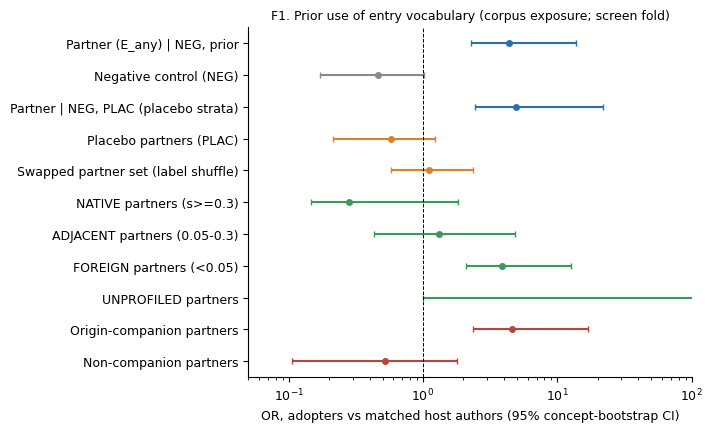

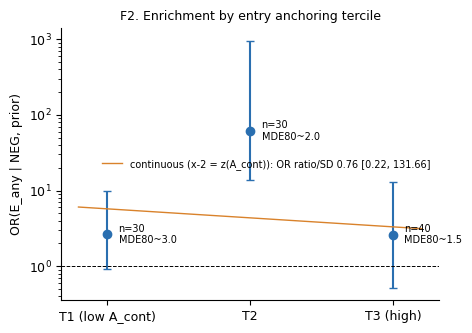

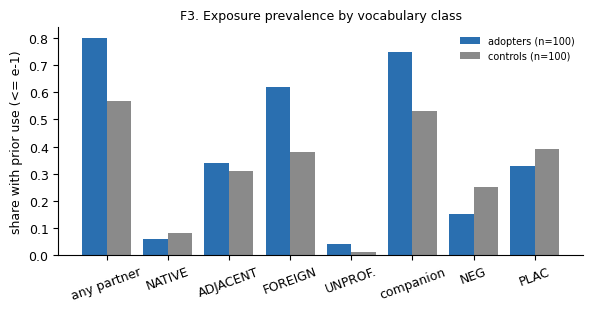

In [17]:
# --- src/figs.py (verbatim plotting functions; _save shows inline instead of writing PNG + PDF) ---
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42})
BLUE, ORANGE, GREY, GREEN, RED = "#2a6fb0", "#d9822b", "#8a8a8a", "#3a9a5b", "#b8433a"


def _save(fig, out: Path, name: str) -> None:
    if name == "F1_forest_ORs":  # demo only: cap the axis - with 100 strata some classes (UNPROFILED) are quasi-separated
        fig.axes[0].set_xlim(0.05, 100)
    fig.tight_layout()
    plt.show()  # original: fig.savefig(out / f"{name}.png", dpi=200); fig.savefig(out / f"{name}.pdf"); plt.close(fig)


def _term(m: dict, t: str):
    v = (m.get("terms") or {}).get(t)
    if not v or v.get("OR") is None:
        return None
    ci = v.get("OR_ci95_boot") or [np.nan, np.nan]
    return v["OR"], ci[0], ci[1]


def f1_forest(res: dict, out: Path) -> None:
    en, voc = res["enrichment"], res["vocab_class"]
    items = [("Partner (E_any) | NEG, prior", en["m2"], "E_any", BLUE),
             ("Negative control (NEG)", en["m2"], "E_neg", GREY),
             ("Partner | NEG, PLAC (placebo strata)", en["m_plac"], "E_any", BLUE),
             ("Placebo partners (PLAC)", en["m_plac"], "E_plac", ORANGE),
             ("Swapped partner set (label shuffle)", en["m_swap"], "E_swap", ORANGE),
             ("NATIVE partners (s>=0.3)", voc["m_voc"], "E_nat", GREEN),
             ("ADJACENT partners (0.05-0.3)", voc["m_voc"], "E_adj", GREEN),
             ("FOREIGN partners (<0.05)", voc["m_voc"], "E_for", GREEN),
             ("UNPROFILED partners", voc["m_voc"], "E_unprof", GREEN),
             ("Origin-companion partners", voc["m_comp"], "E_comp", RED),
             ("Non-companion partners", voc["m_comp"], "E_noncomp", RED)]
    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    ys = []
    for i, (lab, m, t, col) in enumerate(items):
        v = _term(m, t)
        y = len(items) - i
        ys.append((y, lab))
        if v is None:
            ax.text(1, y, "not identified", va="center", fontsize=7, color=GREY)
            continue
        o, lo, hi = v
        ax.errorbar(o, y, xerr=[[max(o - lo, 0)], [max(hi - o, 0)]] if np.isfinite(lo) else None, fmt="o", color=col, ms=4, capsize=2)  # demo: clip (point can fall outside a small-sample percentile CI)
    ax.axvline(1, color="k", lw=0.7, ls="--")
    ax.set_xscale("log")
    ax.set_yticks([y for y, _ in ys])
    ax.set_yticklabels([lab for _, lab in ys])
    ax.set_xlabel("OR, adopters vs matched host authors (95% concept-bootstrap CI)")
    ax.set_title("F1. Prior use of entry vocabulary (corpus exposure; screen fold)", fontsize=9)
    _save(fig, out, "F1_forest_ORs")


def f2_tercile(res: dict, out: Path) -> None:
    it = res["interaction"]
    fig, ax = plt.subplots(figsize=(4.8, 3.4))
    xs, os_ = [], []
    for t in (1, 2, 3):
        v = _term(it.get(f"m2_T{t}") or {}, "E_any")
        if v is None:
            continue
        o, lo, hi = v
        ax.errorbar(t, o, yerr=[[max(o - lo, 0)], [max(hi - o, 0)]] if np.isfinite(lo) else None, fmt="o", color=BLUE, capsize=3)  # demo: clip
        mde = (it["tercile_MDE"].get(f"T{t}") or {}).get("MDE80_p0_0.25")
        ax.text(t + 0.08, o, f"n={it[f'm2_T{t}']['n_strata']}\nMDE80~{mde}", fontsize=7, va="center")
        xs.append(t)
        os_.append(o)
    vi = _term(it["m_int"], "E_any_x_zA")
    v0 = _term(it["m_int"], "E_any")
    if vi and v0:
        zz = np.linspace(-1.2, 1.2, 50)
        ax.plot(2 + zz, np.exp(np.log(v0[0]) + np.log(vi[0]) * zz), color=ORANGE, lw=1,
                label=f"continuous (x-2 = z(A_cont)): OR ratio/SD {vi[0]:.2f} [{vi[1]:.2f}, {vi[2]:.2f}]")
        ax.legend(fontsize=7, frameon=False)
    ax.axhline(1, color="k", lw=0.7, ls="--")
    ax.set_yscale("log")
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["T1 (low A_cont)", "T2", "T3 (high)"])
    ax.set_ylabel("OR(E_any | NEG, prior)")
    ax.set_title("F2. Enrichment by entry anchoring tercile", fontsize=9)
    _save(fig, out, "F2_OR_by_Acont_tercile")


def f3_prevalence(res: dict, out: Path) -> None:
    ds = res["descriptives"]
    labs = [("E_any", "any partner"), ("E_nat", "NATIVE"), ("E_adj", "ADJACENT"), ("E_for", "FOREIGN"),
            ("E_unprof", "UNPROF."), ("E_comp", "companion"), ("E_neg", "NEG"), ("E_plac", "PLAC")]
    x = np.arange(len(labs))
    fig, ax = plt.subplots(figsize=(6.0, 3.2))
    ax.bar(x - 0.2, [ds[f"prev_case_{k}"] for k, _ in labs], 0.4, color=BLUE, label=f"adopters (n={ds['n_cases']})")
    ax.bar(x + 0.2, [ds[f"prev_control_{k}"] for k, _ in labs], 0.4, color=GREY, label=f"controls (n={ds['n_controls']})")
    ax.set_xticks(x)
    ax.set_xticklabels([l for _, l in labs], rotation=20)
    ax.set_ylabel("share with prior use (<= e-1)")
    ax.legend(frameon=False, fontsize=7)
    ax.set_title("F3. Exposure prevalence by vocabulary class", fontsize=9)
    _save(fig, out, "F3_exposure_prevalence")




out = Path(".")
f1_forest(res, out)
f2_tercile(res, out)
f3_prevalence(res, out)